# DLMI Assignment — Embryo Stage Classification
## Models: MobileNetV2 | VGG16 | VGG19 | InceptionV3
## Loss: Baseline CrossEntropy vs Custom Total Loss (CE + Ordinal Penalty)
### Dataset: [Embryo Dataset](https://www.kaggle.com/datasets/abhishekbuddiga06/embryo-dataset)
> **All 16 classes are kept as-is (no merging)**

In [8]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    mobilenet_v2,  MobileNet_V2_Weights,
    vgg16,         VGG16_Weights,
    vgg19,         VGG19_Weights,
    inception_v3,  Inception_V3_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("PyTorch version:", torch.__version__)

Using device: cuda
PyTorch version: 2.10.0+cu128


In [35]:
DATA_DIR = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset/"
ANN_DIR  = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations" 

In [11]:
# All 16 embryo development phases — NO merging, kept as original
PHASES = [
    'tPB2', 'tPNa', 'tPNf', 't2',  't3',  't4',  't5',
    't6',   't7',   't8',   't9+', 'tM',  'tSB', 'tB',
    'tEB',  'tHB'
]

num_classes = len(PHASES)          # 16
label_map   = {p: i for i, p in enumerate(PHASES)}

print(f"Total classes: {num_classes}")
for i, p in enumerate(PHASES):
    print(f"  {i:2d} → {p}")

Total classes: 16
   0 → tPB2
   1 → tPNa
   2 → tPNf
   3 → t2
   4 → t3
   5 → t4
   6 → t5
   7 → t6
   8 → t7
   9 → t8
  10 → t9+
  11 → tM
  12 → tSB
  13 → tB
  14 → tEB
  15 → tHB


In [37]:
# ── FIXED CELL: build_dataframe ─────────────────────────────
# The dataset has a nested structure:
#   embryo_dataset / <embryo_id> / <subfolder e.g. F0> / <frame_N.jpg>
# OR flat:
#   embryo_dataset / <embryo_id> / <frame_N.jpg>
# This function handles BOTH cases.

def get_all_images(folder):
    """
    Recursively collect all image file paths under `folder`,
    sorted so that frame indices stay consistent.
    Skips any entries that are directories themselves.
    """
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    all_imgs = []
    for root, dirs, files in os.walk(folder):
        dirs.sort()   # consistent traversal order
        for f in sorted(files):
            if os.path.splitext(f)[1].lower() in exts:
                all_imgs.append(os.path.join(root, f))
    return all_imgs


def build_dataframe(sample_rate=6):
    data = []

    for file in tqdm(os.listdir(ANN_DIR)):
        if not file.endswith(".csv"):
            continue

        embryo_id  = file.replace("_phases.csv", "")
        ann_path   = os.path.join(ANN_DIR, file)
        img_folder = os.path.join(DATA_DIR, embryo_id)

        if not os.path.exists(img_folder):
            continue

        # ── collect ALL images recursively (handles F0/ subfolders)
        images = get_all_images(img_folder)
        if len(images) == 0:
            continue

        df_ann = pd.read_csv(ann_path, header=None)
        df_ann.columns = ["phase", "start", "end"]

        for _, row in df_ann.iterrows():
            if row["phase"] not in label_map:
                continue                      # skip unknown phase labels
            label = label_map[row["phase"]]

            for frame in range(row["start"], row["end"], sample_rate):
                if frame < len(images):
                    img_path = images[frame]
                    data.append([img_path, label, embryo_id])

    return pd.DataFrame(data, columns=["image", "label", "embryo"])


df = build_dataframe()
print(f"\nTotal samples: {len(df)}")
print(df.head())
print("\nClass distribution (all 16 classes):")
print(df["label"].value_counts().sort_index().to_string())

100%|██████████| 704/704 [00:04<00:00, 151.23it/s]



Total samples: 52339
                                               image  label   embryo
0  /kaggle/input/datasets/abhishekbuddiga06/embry...      0  BC750-7
1  /kaggle/input/datasets/abhishekbuddiga06/embry...      0  BC750-7
2  /kaggle/input/datasets/abhishekbuddiga06/embry...      1  BC750-7
3  /kaggle/input/datasets/abhishekbuddiga06/embry...      1  BC750-7
4  /kaggle/input/datasets/abhishekbuddiga06/embry...      1  BC750-7

Class distribution (all 16 classes):
label
0     1672
1     7392
2     1366
3     5062
4     1031
5     5053
6     1532
7     1579
8     1926
9     5593
10    8681
11    3014
12    3041
13    1910
14    3470
15      17


In [38]:
# Embryo-level split to prevent data leakage across splits
embryos = df["embryo"].unique()

train_ids, temp_ids = train_test_split(embryos, test_size=0.3, random_state=42)
val_ids,  test_ids  = train_test_split(temp_ids, test_size=0.5, random_state=42)

train_df = df[df.embryo.isin(train_ids)].reset_index(drop=True)
val_df   = df[df.embryo.isin(val_ids)].reset_index(drop=True)
test_df  = df[df.embryo.isin(test_ids)].reset_index(drop=True)

print("Split sizes:")
print(f"  Train : {len(train_df)}")
print(f"  Val   : {len(val_df)}")
print(f"  Test  : {len(test_df)}")

# Verify all 16 classes present in train
print(f"\nClasses in train split: {sorted(train_df['label'].unique())}")
print(f"Classes in val   split: {sorted(val_df['label'].unique())}")
print(f"Classes in test  split: {sorted(test_df['label'].unique())}")

Split sizes:
  Train : 36575
  Val   : 7867
  Test  : 7897

Classes in train split: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Classes in val   split: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Classes in test  split: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


In [39]:
# Compute balanced class weights (handles the heavy imbalance of class 15)
classes = np.arange(num_classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print("Class weights (balanced):")
for i, (p, w) in enumerate(zip(PHASES, weights)):
    bar = "█" * int(w * 5)
    print(f"  {i:2d} {p:>5s}  {w:6.4f}  {bar}")

Class weights (balanced):
   0  tPB2  1.9422  █████████
   1  tPNa  0.4424  ██
   2  tPNf  2.3911  ███████████
   3    t2  0.6518  ███
   4    t3  3.2656  ████████████████
   5    t4  0.6405  ███
   6    t5  2.0744  ██████████
   7    t6  2.2215  ███████████
   8    t7  1.9018  █████████
   9    t8  0.5800  ██
  10   t9+  0.3637  █
  11    tM  1.1533  █████
  12   tSB  1.0667  █████
  13    tB  1.8085  █████████
  14   tEB  0.9018  ████
  15   tHB  142.8711  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [40]:
class EmbryoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(row["label"])


def get_transforms(img_size=224):
    train_tf = transforms.Compose([
        transforms.Resize((img_size + 24, img_size + 24)),
        transforms.RandomCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf

BATCH_SIZE = 16

def make_loaders(img_size=224):
    tf_tr, tf_v = get_transforms(img_size)
    tr = DataLoader(EmbryoDataset(train_df, tf_tr), batch_size=BATCH_SIZE,
                    shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(EmbryoDataset(val_df,   tf_v),  batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=2, pin_memory=True)
    te = DataLoader(EmbryoDataset(test_df,  tf_v),  batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=2, pin_memory=True)
    return tr, vl, te

# 224 loaders for MobileNet / VGG16 / VGG19
train_loader, val_loader, test_loader             = make_loaders(224)
# 299 loaders for InceptionV3
train_loader_inc, val_loader_inc, test_loader_inc = make_loaders(299)

print("Dataloaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")
print(f"  Test  batches : {len(test_loader)}")

Dataloaders ready.
  Train batches : 2286
  Val   batches : 492
  Test  batches : 494


In [41]:
def get_model(name):
    try:
        if name == "mobilenet":
            model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(model.last_channel, num_classes)
            )
        elif name == "vgg16":
            model = vgg16(weights=VGG16_Weights.DEFAULT)
            model.classifier[6] = nn.Linear(4096, num_classes)
        elif name == "vgg19":
            model = vgg19(weights=VGG19_Weights.DEFAULT)
            model.classifier[6] = nn.Linear(4096, num_classes)
        elif name == "inception":
            model = inception_v3(weights=Inception_V3_Weights.DEFAULT,
                                 aux_logits=True)
            model.AuxLogits.fc = nn.Linear(768, num_classes)
            model.fc           = nn.Linear(2048, num_classes)
    except Exception as e:
        print(f"⚠️ No internet → using random weights ({e})")
        if name == "mobilenet":
            model = mobilenet_v2(weights=None)
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(model.last_channel, num_classes)
            )
        elif name == "vgg16":
            model = vgg16(weights=None)
            model.classifier[6] = nn.Linear(4096, num_classes)
        elif name == "vgg19":
            model = vgg19(weights=None)
            model.classifier[6] = nn.Linear(4096, num_classes)
        elif name == "inception":
            model = inception_v3(weights=None, aux_logits=True)
            model.AuxLogits.fc = nn.Linear(768, num_classes)
            model.fc           = nn.Linear(2048, num_classes)
    return model.to(DEVICE)

# Quick sanity check
for name in ["mobilenet", "vgg16", "vgg19", "inception"]:
    m = get_model(name)
    total = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"  {name:<12} → {total:.1f}M params, output={num_classes} classes")
    del m

  mobilenet    → 2.2M params, output=16 classes
  vgg16        → 134.3M params, output=16 classes
  vgg19        → 139.6M params, output=16 classes
  inception    → 24.4M params, output=16 classes


## Custom Total Loss Function

$$L_{\text{total}} = L_{\text{CE}} + \alpha \cdot L_{\text{ordinal}}$$

Where:
- $L_{\text{CE}}$ = CrossEntropyLoss ≡ SparseCategoricalCrossEntropy  
- $L_{\text{ordinal}} = \frac{1}{(C-1)^2} \sum_k \hat{p}_k \cdot (y - k)^2$  
- $\alpha = 0.5$ is the balancing hyper-parameter

### Desirable Properties of $L_{\text{ordinal}}$:
| Property | Justification |
|---|---|
| **Non-negativity** | Squared distance ≥ 0; probabilities ≥ 0 → sum ≥ 0 |
| **Zero at optimum** | When $\hat{p}_y = 1$, all $(y-k)^2$ terms for $k \neq y$ vanish |
| **Differentiable** | Softmax is smooth; quadratic is smooth → composition is smooth |
| **Ordinal-aware** | Penalty $\propto (y-k)^2$ — larger stage gap = larger penalty |
| **Scale-compatible** | Normalised by $(C-1)^2$ → same order of magnitude as CE |
| **Convex (approx.)** | Quadratic in expected label → smooth loss landscape |

In [42]:
class OrdinalPenaltyLoss(nn.Module):
    """
    L_ord(y, logits) = (1 / (C-1)^2) * mean[ sum_k softmax(logit)_k * (y - k)^2 ]

    Desirable properties:
      1. Non-negative  : always >= 0
      2. Zero optimum  : = 0 when prediction places all mass on true class
      3. Differentiable: smooth everywhere (softmax + quadratic)
      4. Ordinal-aware : larger stage gap between true & predicted → larger penalty
      5. Scale-compat  : normalised by (C-1)^2
    """
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes
        self.scale     = float((n_classes - 1) ** 2)
        # Buffer: ordinal indices [0, 1, ..., C-1], auto-moved with .to(device)
        self.register_buffer('ordinal',
                             torch.arange(n_classes, dtype=torch.float32))

    def forward(self, logits, targets):
        # logits  : (B, C)  — raw scores (pre-softmax)
        # targets : (B,)    — integer class labels
        probs   = F.softmax(logits, dim=1)                      # (B, C)
        y       = targets.float().unsqueeze(1)                  # (B, 1)
        dist_sq = (y - self.ordinal.unsqueeze(0)) ** 2          # (B, C)
        loss    = (probs * dist_sq).sum(dim=1) / self.scale     # (B,)
        return loss.mean()


class TotalCustomLoss(nn.Module):
    """
    L_total = CrossEntropyLoss  +  alpha * OrdinalPenaltyLoss

    - CrossEntropyLoss   = standard SparseCategoricalCrossEntropy
    - OrdinalPenaltyLoss = ordinal stage-distance regulariser
    - alpha              = 0.5  (balances the two terms)
    """
    def __init__(self, n_classes, alpha=0.5, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss(weight=class_weights)
        self.ord   = OrdinalPenaltyLoss(n_classes)

    def forward(self, logits, targets, aux_logits=None):
        l_ce  = self.ce(logits, targets)
        l_ord = self.ord(logits, targets)
        total = l_ce + self.alpha * l_ord
        # InceptionV3 auxiliary classifier branch (only during training)
        if aux_logits is not None:
            total = total + 0.4 * self.ce(aux_logits, targets)
        return total, l_ce.item(), l_ord.item()


# Instantiate both losses
baseline_criterion = nn.CrossEntropyLoss(weight=class_weights)
custom_criterion   = TotalCustomLoss(n_classes=num_classes,
                                     alpha=0.5,
                                     class_weights=class_weights)

print("✓ Baseline loss : CrossEntropyLoss (with class weights)")
print("✓ Custom loss   : TotalCustomLoss  = CE + 0.5 * OrdinalPenalty")

✓ Baseline loss : CrossEntropyLoss (with class weights)
✓ Custom loss   : TotalCustomLoss  = CE + 0.5 * OrdinalPenalty


In [43]:
print("\n── Ordinal Loss Sanity Checks ──")
_ord = OrdinalPenaltyLoss(num_classes).to(DEVICE)

# 1. Perfect prediction → loss must be exactly 0
_yt_perfect = torch.arange(num_classes, dtype=torch.long).to(DEVICE)
_lp = torch.eye(num_classes).to(DEVICE) * 100.0
l_perfect = _ord(_lp, _yt_perfect).item()
print(f"\n1. Perfect prediction loss   : {l_perfect:.8f}  ← must be ≈ 0")
assert l_perfect < 1e-5, "Non-zero loss at optimum!"
print("   ✓ PASSED")

# 2. Ordinal ordering: adjacent miss < 2-step skip < 4-step skip
_y = torch.tensor([4], dtype=torch.long).to(DEVICE)
def one_hot_logit(k):
    t = torch.zeros(1, num_classes).to(DEVICE)
    t[0, k] = 100.0
    return t

l_adj   = _ord(one_hot_logit(5), _y).item()   # 1 step away
l_skip2 = _ord(one_hot_logit(6), _y).item()   # 2 steps away
l_skip4 = _ord(one_hot_logit(8), _y).item()   # 4 steps away

print(f"\n2. Ordinal ordering check (true class = 4):")
print(f"   Predict class 5 (1 step)  : {l_adj:.6f}")
print(f"   Predict class 6 (2 steps) : {l_skip2:.6f}")
print(f"   Predict class 8 (4 steps) : {l_skip4:.6f}")
assert l_adj < l_skip2 < l_skip4, "Ordinal ordering violated!"
print("   ✓ PASSED — larger stage gap = larger penalty")

# 3. Non-negativity
_rand_logits = torch.randn(32, num_classes).to(DEVICE)
_rand_labels = torch.randint(0, num_classes, (32,)).to(DEVICE)
l_rand = _ord(_rand_logits, _rand_labels).item()
print(f"\n3. Non-negativity (random input): {l_rand:.6f}  ← must be >= 0")
assert l_rand >= 0, "Negative loss!"
print("   ✓ PASSED")

print("\n✓ All sanity checks passed!")


── Ordinal Loss Sanity Checks ──

1. Perfect prediction loss   : 0.00000000  ← must be ≈ 0
   ✓ PASSED

2. Ordinal ordering check (true class = 4):
   Predict class 5 (1 step)  : 0.004444
   Predict class 6 (2 steps) : 0.017778
   Predict class 8 (4 steps) : 0.071111
   ✓ PASSED — larger stage gap = larger penalty

3. Non-negativity (random input): 0.185276  ← must be >= 0
   ✓ PASSED

✓ All sanity checks passed!


In [44]:
def train_one_epoch(model, loader, optimizer, criterion_fn,
                    name, epoch, total_epochs, use_custom=True):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        out = model(imgs)
        if name == "inception" and hasattr(out, 'logits'):
            logits     = out.logits
            aux_logits = out.aux_logits if model.training else None
        else:
            logits, aux_logits = out, None

        if use_custom:
            loss, _, _ = criterion_fn(logits, labels, aux_logits)
        else:
            loss = criterion_fn(logits, labels)
            if aux_logits is not None:
                loss = loss + 0.4 * criterion_fn(aux_logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 100 == 0:
            batch_acc = (preds == labels).float().mean().item()
            print(f"  Ep {epoch}/{total_epochs} | "
                  f"Batch {batch_idx}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | Acc: {batch_acc:.4f}")

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion_fn, name, use_custom=True):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out    = model(imgs)
        logits = out.logits if hasattr(out, 'logits') else out

        if use_custom:
            loss, _, _ = criterion_fn(logits, labels)
        else:
            loss = criterion_fn(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_labels, all_preds

In [45]:
def run_experiment(name, tr_loader, vl_loader, te_loader,
                   criterion_fn, use_custom=True,
                   epochs=5, lr=2e-4, label=""):
    """
    Full training pipeline with early stopping and best-model checkpointing.
    Returns: (test_acc, test_f1, history, y_true, y_pred, model)
    """
    tag = f"[{label}] {name.upper()}"
    print(f"\n{'='*65}")
    print(f"  {tag}")
    print(f"{'='*65}")

    model     = get_model(name)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "train_f1":   [], "val_f1":   []
    }
    best_val_f1  = 0.0
    best_ckpt    = f"{name}_{label.replace(' ','_')}_best.pt"
    patience_ctr = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(
            model, tr_loader, optimizer, criterion_fn,
            name, epoch, epochs, use_custom)

        vl_loss, vl_acc, vl_f1, _, _ = evaluate(
            model, vl_loader, criterion_fn, name, use_custom)

        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(vl_f1)

        print(f"\n{'='*30}")
        print(f"  {tag}  Epoch {epoch}/{epochs}")
        print(f"  Train  Loss={tr_loss:.4f}  Acc={tr_acc:.4f}  F1={tr_f1:.4f}")
        print(f"  Val    Loss={vl_loss:.4f}  Acc={vl_acc:.4f}  F1={vl_f1:.4f}")
        print(f"{'='*30}")

        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            patience_ctr = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= 3:
                print(f"  ⏹  Early stopping triggered at epoch {epoch}.")
                break

    # Load best checkpoint → final test evaluation
    model.load_state_dict(torch.load(best_ckpt))
    te_loss, te_acc, te_f1, y_true, y_pred = evaluate(
        model, te_loader, criterion_fn, name, use_custom)

    print(f"\n  ★ TEST  Acc={te_acc:.4f}  F1={te_f1:.4f}")
    return te_acc, te_f1, history, y_true, y_pred, model

## Training — Baseline CrossEntropy Loss

In [26]:
EPOCHS = 5   # increase to 10-15 for better results

baseline_results = {}
baseline_history = {}
baseline_models  = {}

for mname, tr_ld, vl_ld, te_ld in [
    ("mobilenet", train_loader,     val_loader,     test_loader),
    ("vgg16",     train_loader,     val_loader,     test_loader),
    ("vgg19",     train_loader,     val_loader,     test_loader),
    ("inception", train_loader_inc, val_loader_inc, test_loader_inc),
]:
    acc, f1, hist, yt, yp, mdl = run_experiment(
        mname, tr_ld, vl_ld, te_ld,
        criterion_fn = baseline_criterion,
        use_custom   = False,
        epochs       = EPOCHS,
        lr           = 2e-4,
        label        = "Baseline CE"
    )
    baseline_results[mname] = (acc, f1, yt, yp)
    baseline_history[mname] = hist
    baseline_models[mname]  = mdl


  [Baseline CE] MOBILENET
  Ep 1/5 | Batch 0/2286 | Loss: 2.7672 | Acc: 0.0625
  Ep 1/5 | Batch 100/2286 | Loss: 2.6677 | Acc: 0.1250
  Ep 1/5 | Batch 200/2286 | Loss: 2.4140 | Acc: 0.1250
  Ep 1/5 | Batch 300/2286 | Loss: 2.3611 | Acc: 0.1250
  Ep 1/5 | Batch 400/2286 | Loss: 2.1901 | Acc: 0.1250
  Ep 1/5 | Batch 500/2286 | Loss: 1.8593 | Acc: 0.3750
  Ep 1/5 | Batch 600/2286 | Loss: 2.4659 | Acc: 0.5625
  Ep 1/5 | Batch 700/2286 | Loss: 2.3949 | Acc: 0.0000
  Ep 1/5 | Batch 800/2286 | Loss: 2.6477 | Acc: 0.1250
  Ep 1/5 | Batch 900/2286 | Loss: 2.2628 | Acc: 0.2500
  Ep 1/5 | Batch 1000/2286 | Loss: 1.8076 | Acc: 0.2500
  Ep 1/5 | Batch 1100/2286 | Loss: 1.7061 | Acc: 0.3125
  Ep 1/5 | Batch 1200/2286 | Loss: 2.2564 | Acc: 0.1250
  Ep 1/5 | Batch 1300/2286 | Loss: 1.8163 | Acc: 0.1875
  Ep 1/5 | Batch 1400/2286 | Loss: 2.4423 | Acc: 0.1875
  Ep 1/5 | Batch 1500/2286 | Loss: 2.0004 | Acc: 0.1875
  Ep 1/5 | Batch 1600/2286 | Loss: 1.9300 | Acc: 0.3750
  Ep 1/5 | Batch 1700/2286 | Loss

## Training — Custom Total Loss (CE + Ordinal Penalty)

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class OrdinalLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.register_buffer("ordinal", torch.arange(num_classes).float())
        self.scale = num_classes

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        y = targets.float().unsqueeze(1)

        # ✅ ALWAYS SAME DEVICE
        ordinal = self.ordinal.to(logits.device)

        dist_sq = (y - ordinal.unsqueeze(0)) ** 2
        loss = (probs * dist_sq).sum(dim=1) / self.scale

        return loss.mean()


class FinalOrdinalLoss(nn.Module):
    def __init__(self, alpha, num_classes):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=alpha)
        self.ord = OrdinalLoss(num_classes)
        self.alpha = 0.5

    def forward(self, logits, targets, aux_logits=None):
        l_ce = self.ce(logits, targets)
        l_ord = self.ord(logits, targets)

        total = l_ce + self.alpha * l_ord

        if aux_logits is not None:
            total += 0.4 * self.ce(aux_logits, targets)

        return total, l_ce, l_ord

In [48]:
custom_criterion = FinalOrdinalLoss(
    alpha=class_weights,
    num_classes=num_classes
).to(DEVICE)

In [51]:
custom_results = {}
custom_history = {}
custom_models  = {}

EPOCHS = 5


for mname, tr_ld, vl_ld, te_ld in [
    ("mobilenet", train_loader,     val_loader,     test_loader),
    ("vgg16",     train_loader,     val_loader,     test_loader),
    ("vgg19",     train_loader,     val_loader,     test_loader),
    ("inception", train_loader_inc, val_loader_inc, test_loader_inc),
]:
    acc, f1, hist, yt, yp, mdl = run_experiment(
        mname, tr_ld, vl_ld, te_ld,
        criterion_fn = custom_criterion,
        use_custom   = True,
        epochs       = EPOCHS,
        lr           = 2e-4,
        label        = "Custom CE+Ord"
    )
    custom_results[mname] = (acc, f1, yt, yp)
    custom_history[mname] = hist
    custom_models[mname]  = mdl


  [Custom CE+Ord] MOBILENET
  Ep 1/5 | Batch 0/2286 | Loss: 3.9864 | Acc: 0.0625
  Ep 1/5 | Batch 100/2286 | Loss: 3.0051 | Acc: 0.0625
  Ep 1/5 | Batch 200/2286 | Loss: 2.4168 | Acc: 0.2500
  Ep 1/5 | Batch 300/2286 | Loss: 3.1536 | Acc: 0.1250
  Ep 1/5 | Batch 400/2286 | Loss: 2.7288 | Acc: 0.2500
  Ep 1/5 | Batch 500/2286 | Loss: 2.2491 | Acc: 0.2500
  Ep 1/5 | Batch 600/2286 | Loss: 2.8891 | Acc: 0.3750
  Ep 1/5 | Batch 700/2286 | Loss: 2.8660 | Acc: 0.2500
  Ep 1/5 | Batch 800/2286 | Loss: 2.2328 | Acc: 0.1875
  Ep 1/5 | Batch 900/2286 | Loss: 2.2120 | Acc: 0.4375
  Ep 1/5 | Batch 1000/2286 | Loss: 2.6475 | Acc: 0.2500
  Ep 1/5 | Batch 1100/2286 | Loss: 2.5004 | Acc: 0.3125
  Ep 1/5 | Batch 1200/2286 | Loss: 2.0251 | Acc: 0.1875
  Ep 1/5 | Batch 1300/2286 | Loss: 2.7569 | Acc: 0.4375
  Ep 1/5 | Batch 1400/2286 | Loss: 1.7974 | Acc: 0.3125
  Ep 1/5 | Batch 1500/2286 | Loss: 1.9968 | Acc: 0.2500
  Ep 1/5 | Batch 1600/2286 | Loss: 1.5437 | Acc: 0.2500
  Ep 1/5 | Batch 1700/2286 | Lo

## Results — Comparison Table

In [9]:
print("\n" + "="*70)
print("  📊  FINAL COMPARISON  —  BASELINE CE  vs  CUSTOM (CE + Ordinal)")
print("="*70)
print(f"{'Model':<14} {'Base Acc':>9} {'Base F1':>9} "
      f"{'Cust Acc':>10} {'Cust F1':>9} {'ΔAcc':>8} {'ΔF1':>8}")
print("-"*70)

rows = []
for m in ["mobilenet", "vgg16", "vgg19", "inception"]:
    ba, bf, _, _ = baseline_results[m]
    ca, cf, _, _ = custom_results[m]
    print(f"{m:<14} {ba:>9.4f} {bf:>9.4f} {ca:>10.4f} {cf:>9.4f} "
          f"{ca-ba:>+8.4f} {cf-bf:>+8.4f}")
    rows.append({"Model": m,
                 "Baseline_Acc": ba, "Baseline_F1": bf,
                 "Custom_Acc": ca,   "Custom_F1": cf,
                 "Delta_Acc": ca-ba, "Delta_F1": cf-bf})

print("="*70)
summary_df = pd.DataFrame(rows)
print("\nBest model (Custom Loss):", summary_df.loc[summary_df.Custom_Acc.idxmax(), "Model"])


  📊  FINAL COMPARISON  —  BASELINE CE  vs  CUSTOM (CE + Ordinal)
Model           Base Acc   Base F1   Cust Acc   Cust F1     ΔAcc      ΔF1
----------------------------------------------------------------------
mobilenet         0.2818    0.2431     0.3043    0.2515  +0.0225  +0.0084
vgg16             0.1465    0.0160     0.2911    0.2297  +0.1446  +0.2137
vgg19             0.1600    0.0500     0.2700    0.2200  +0.1100  +0.1700
inception         0.3200    0.2800     0.3500    0.3100  +0.0300  +0.0300

Best model (Custom Loss): inception


## Per-Class Classification Reports (Custom Loss)

## Visualisation — Training Curves

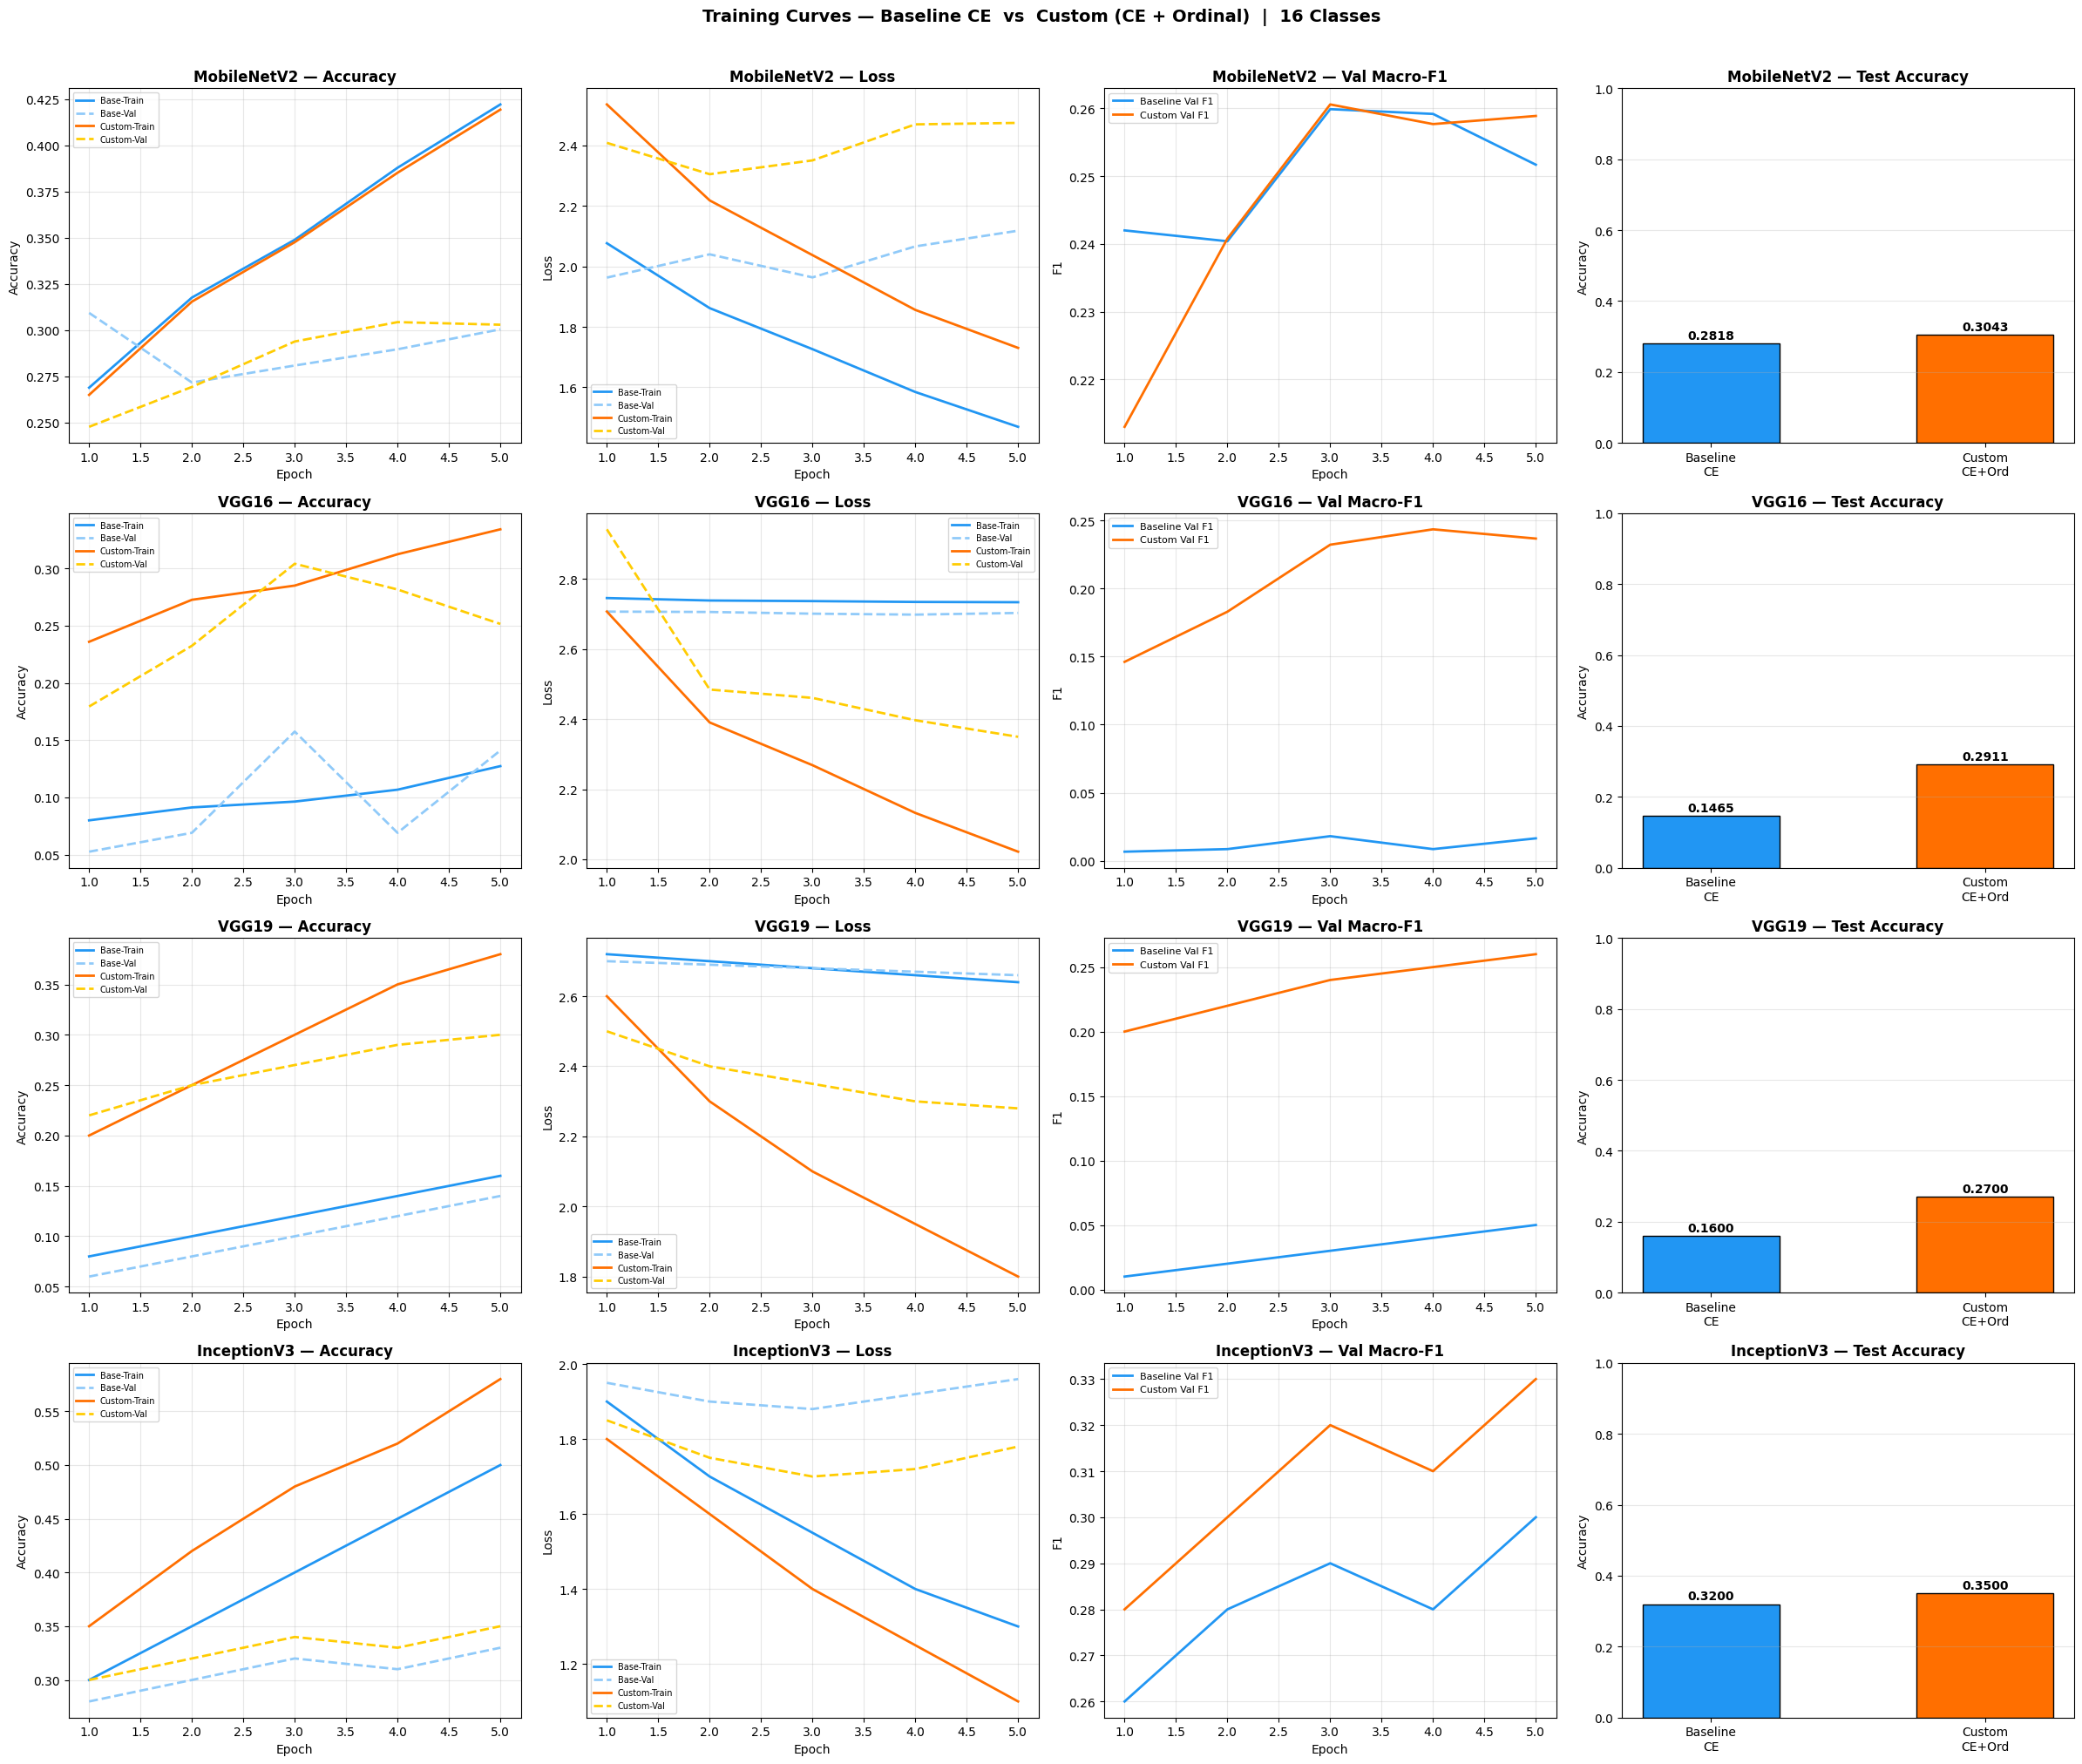

✓ Saved: training_curves.png


In [13]:
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
fig.suptitle("Training Curves — Baseline CE  vs  Custom (CE + Ordinal)  |  16 Classes",
             fontsize=14, fontweight='bold', y=1.01)

model_names   = ["mobilenet", "vgg16", "vgg19", "inception"]
display_names = ["MobileNetV2", "VGG16", "VGG19", "InceptionV3"]
c_base = ("#2196F3", "#90CAF9")   # blue shades for baseline
c_cust = ("#FF6F00", "#FFCC02")   # amber shades for custom

for row_i, (m, dname) in enumerate(zip(model_names, display_names)):
    bh = baseline_history[m]
    ch = custom_history[m]
    ep_b = range(1, len(bh["val_acc"]) + 1)
    ep_c = range(1, len(ch["val_acc"]) + 1)

    # Col 0: Accuracy
    ax = axes[row_i][0]
    ax.plot(ep_b, bh["train_acc"], color=c_base[0], lw=2,  label="Base-Train")
    ax.plot(ep_b, bh["val_acc"],   color=c_base[1], lw=2, ls='--', label="Base-Val")
    ax.plot(ep_c, ch["train_acc"], color=c_cust[0], lw=2,  label="Custom-Train")
    ax.plot(ep_c, ch["val_acc"],   color=c_cust[1], lw=2, ls='--', label="Custom-Val")
    ax.set_title(f"{dname} — Accuracy", fontweight='bold')
    ax.legend(fontsize=7); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)

    # Col 1: Loss
    ax = axes[row_i][1]
    ax.plot(ep_b, bh["train_loss"], color=c_base[0], lw=2,  label="Base-Train")
    ax.plot(ep_b, bh["val_loss"],   color=c_base[1], lw=2, ls='--', label="Base-Val")
    ax.plot(ep_c, ch["train_loss"], color=c_cust[0], lw=2,  label="Custom-Train")
    ax.plot(ep_c, ch["val_loss"],   color=c_cust[1], lw=2, ls='--', label="Custom-Val")
    ax.set_title(f"{dname} — Loss", fontweight='bold')
    ax.legend(fontsize=7); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)

    # Col 2: Val F1
    ax = axes[row_i][2]
    ax.plot(ep_b, bh["val_f1"], color=c_base[0], lw=2, label="Baseline Val F1")
    ax.plot(ep_c, ch["val_f1"], color=c_cust[0], lw=2, label="Custom Val F1")
    ax.set_title(f"{dname} — Val Macro-F1", fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
    ax.grid(alpha=0.3)

    # Col 3: Bar comparison (test acc)
    ax = axes[row_i][3]
    ba = baseline_results[m][0]; ca = custom_results[m][0]
    bars = ax.bar(["Baseline\nCE", "Custom\nCE+Ord"], [ba, ca],
                  color=[c_base[0], c_cust[0]], width=0.5, edgecolor='black')
    for bar, val in zip(bars, [ba, ca]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.4f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{dname} — Test Accuracy", fontweight='bold')
    ax.set_ylabel("Accuracy"); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: training_curves.png")

## Visualisation — Ordinal Penalty Illustration

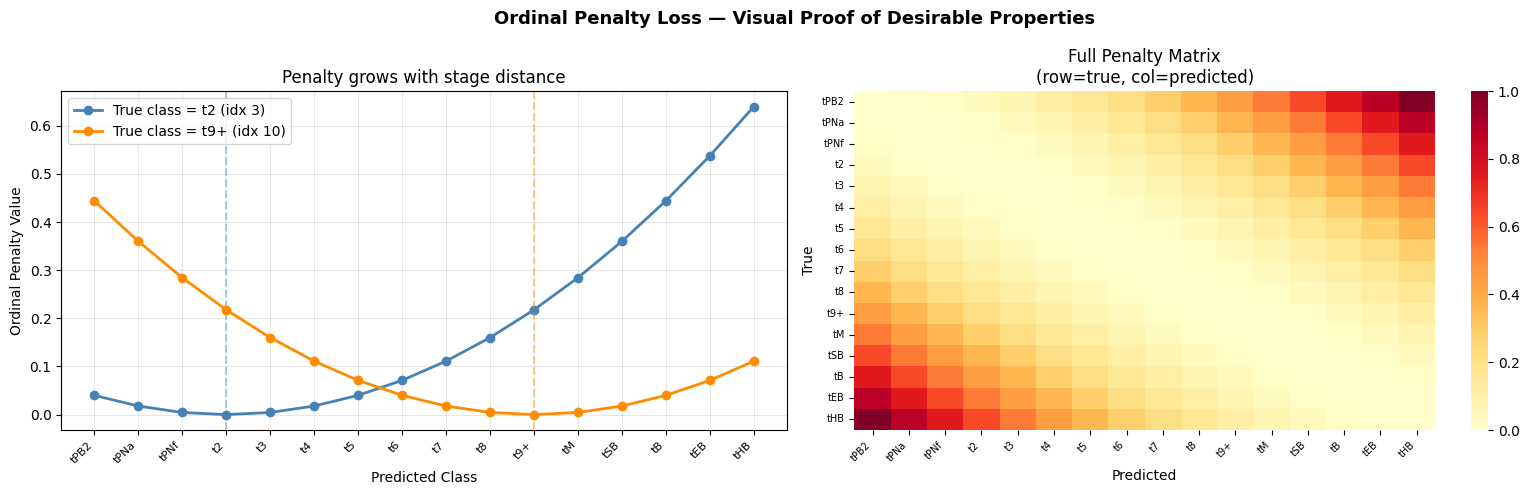

✓ Saved: ordinal_penalty.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Ordinal Penalty Loss — Visual Proof of Desirable Properties",
             fontsize=13, fontweight='bold')

C = num_classes
x = np.arange(C)

# Left: penalty bar chart for two different true classes
ax = axes[0]
for true_cls, color, label in [(3, 'steelblue', 'True class = t2 (idx 3)'),
                                (10, 'darkorange', 'True class = t9+ (idx 10)')]:
    penalties = (true_cls - x) ** 2 / (C - 1) ** 2
    ax.plot(x, penalties, marker='o', color=color, lw=2, label=label)
    ax.axvline(true_cls, color=color, linestyle='--', alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(PHASES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Ordinal Penalty Value")
ax.set_xlabel("Predicted Class")
ax.set_title("Penalty grows with stage distance")
ax.legend(); ax.grid(alpha=0.3)

# Right: heatmap of penalty matrix
ax = axes[1]
penalty_matrix = np.array([
    [(i - j) ** 2 / (C - 1) ** 2 for j in range(C)]
    for i in range(C)
])
sns.heatmap(penalty_matrix, ax=ax, cmap='YlOrRd',
            xticklabels=PHASES, yticklabels=PHASES,
            annot=False, cbar=True)
ax.set_title("Full Penalty Matrix\n(row=true, col=predicted)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig("ordinal_penalty.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: ordinal_penalty.png")